# Video 6: High Content Analysis and Cell Painting
### AI for Drug Discovery Series - DigitalSreeni

In earlier videos we screened compounds computationally using molecular fingerprints and QSAR models. But a compound that looks potent on paper may behave unexpectedly inside a living cell - it might hit the right target but also disrupt the cytoskeleton, change nuclear morphology, or alter mitochondrial structure in ways that predict toxicity or off-target effects.

**High Content Analysis (HCA)** is the bridge between a chemical structure and its actual cellular effect. It uses fluorescence microscopy to image cells, then extracts hundreds of quantitative measurements from those images -- capturing how cells look, not just what they bind.

**Cell Painting** is a specific HCA protocol developed at the Broad Institute. It uses six fluorescent dyes to label eight cellular compartments simultaneously, then extracts thousands of morphological features per well. The result is a rich numerical fingerprint of what a compound does to a cell.

In this notebook we will:
- Understand the Cell Painting assay and what each channel captures
- Explore what CellProfiler-derived morphological features look like
- Load a real published dataset (LINCS Cell Painting, Broad Institute)
- Merge profiles with mechanism-of-action (MoA) annotations
- Use PCA and UMAP to visualize whether compounds with the same MoA cluster together
- Build a hierarchical clustering heatmap of MoA consensus profiles

**Dataset**: LINCS Cell Painting - A549 human lung cells treated with 1,571 compounds across multiple doses.  
**Reference**: Way et al. 2022, Cell Systems. Broad Institute / Connectivity Map team.

In [ ]:
# Install umap-learn (not in Colab by default)
!pip install umap-learn --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import umap
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style across the series
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Part 1: The Cell Painting Assay

### What gets stained and why

Cell Painting uses six fluorescent dyes that target different cellular structures. When a compound perturbs the cell, it changes how these structures look -- and those changes are captured as numbers.

| Channel | Dye | Structure labeled | Biological relevance |
|---------|-----|-------------------|----------------------|
| Ch1 | Hoechst 33342 | DNA / Nucleus | Nuclear shape, size, chromatin texture |
| Ch2 | Concanavalin A + Alexa 488 | Endoplasmic reticulum (ER) | ER stress, protein folding |
| Ch3 | SYTO 14 | RNA / Nucleoli / cytoplasmic RNA | Protein synthesis activity |
| Ch4 | Phalloidin + Alexa 568 | Actin cytoskeleton / Golgi / plasma membrane | Cell shape, motility, Golgi morphology |
| Ch5 | MitoTracker | Mitochondria | Metabolic state, mitochondrial network |

Each well of a 384-well plate is imaged at multiple sites. The images are then processed by **CellProfiler**, which:
1. Segments individual cells and nuclei
2. Measures hundreds of features per cell per channel (intensity, texture, shape, spatial relationships)
3. Aggregates single-cell measurements to a single profile per well

For a deeper look at how feature extraction works on 3D multichannel images, see the 3D organoid segmentation video in this channel (https://youtu.be/WCo1fchV4R8). The same principles apply to 2D Cell Painting images, just with 5 channels instead of 1.

### From images to numbers

A single well might yield features like:
- `Cells_AreaShape_Area` -- average cell area in pixels
- `Nuclei_Intensity_MeanIntensity_DNA` -- average DNA staining intensity per nucleus
- `Cells_Texture_Variance_Mito_10_0` -- variance of mitochondrial texture at scale 10
- `Cytoplasm_Granularity_1_RNA` -- granularity of RNA staining in the cytoplasm

Across all compartments and channels, CellProfiler typically extracts 1,000 to 2,000 features per well. This is the morphological profile of that well.

## Part 2: Load the LINCS Cell Painting Dataset

We are using the LINCS (Library of Integrated Network-Based Cellular Signatures) Cell Painting dataset from the Broad Institute. This is a landmark publicly available resource: A549 human lung cancer cells were treated with 1,571 compounds from the Drug Repurposing Hub, each across 6 doses, and imaged using Cell Painting.

The profiles we load here are **consensus profiles** -- for each compound at each dose, the replicate well profiles have been aggregated into a single representative profile. This gives one row per compound-dose combination.

The data is hosted on GitHub (Broad Institute repository, CC0 license) and loads directly via pandas.

In [ ]:
# Load consensus profiles from the LINCS Cell Painting repository
# These are well-level CellProfiler features aggregated by compound and dose
# Normalization method: median, DMSO-normalized (DMSO = vehicle control)

commit = 'da8ae6a3bc103346095d61b4ee02f08fc85a5d98'
base = f'https://media.githubusercontent.com/media/broadinstitute/lincs-cell-painting/{commit}'

profiles_url = (
    f'{base}/consensus/2016_04_01_a549_48hr_batch1/'
    '2016_04_01_a549_48hr_batch1_consensus_median_dmso.csv.gz'
)

print('Loading LINCS consensus profiles...')
profiles = pd.read_csv(profiles_url, compression='gzip')

# Separate metadata columns (prefixed Metadata_) from feature columns
meta_cols = [c for c in profiles.columns if c.startswith('Metadata_')]
feature_cols = [c for c in profiles.columns if not c.startswith('Metadata_')]

print(f'Profiles shape: {profiles.shape}')
print(f'Metadata columns: {meta_cols}')
print(f'Number of morphological features: {len(feature_cols)}')
print(f'Dose levels (recode 0-7): {sorted(profiles["Metadata_dose_recode"].unique())}')
print(f'Unique compounds: {profiles["Metadata_broad_sample"].nunique()}')

Loading LINCS consensus profiles...
Profiles shape: (10752, 1788)
Metadata columns: ['Metadata_Plate_Map_Name', 'Metadata_broad_sample', 'Metadata_pert_well', 'Metadata_mmoles_per_liter', 'Metadata_dose_recode']
Number of morphological features: 1783
Dose levels (recode 0-7): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Unique compounds: 1571


### Understanding the feature names

CellProfiler feature names follow a consistent naming convention:

```
<Compartment>_<FeatureFamily>_<Measurement>_<Channel>_<Scale>
```

For example, `Nuclei_Texture_Variance_RNA_10_0` means:
- **Compartment**: Nuclei (measurement taken inside the nucleus)
- **Feature family**: Texture
- **Measurement**: Variance
- **Channel**: RNA (SYTO 14 stain)
- **Scale**: 10 pixels

The three compartments are `Cells` (whole cell), `Nuclei` (nucleus only), and `Cytoplasm` (cell minus nucleus). The feature families are `AreaShape`, `Intensity`, `Texture`, `Granularity`, `RadialDistribution`, and `Neighbors`.

In [ ]:
# Explore the feature space structure
# Parse compartment and feature family from column names

compartments = {}
for col in feature_cols:
    parts = col.split('_')
    if len(parts) >= 2:
        comp = parts[0]       # Cells, Nuclei, Cytoplasm
        family = parts[1]     # AreaShape, Intensity, Texture, etc.
        key = f'{comp} - {family}'
        compartments[key] = compartments.get(key, 0) + 1

print('Feature counts by compartment and measurement family:\n')
for k, v in sorted(compartments.items(), key=lambda x: -x[1]):
    print(f'  {k:<40} {v:>4} features')

print(f'\nExample feature names from each family:')
for family in ['AreaShape', 'Intensity', 'Texture', 'Granularity']:
    examples = [c for c in feature_cols if f'_{family}_' in c][:2]
    print(f'  {family}: {examples}')

Feature counts by compartment and measurement family:

  Cells - Texture                           210 features
  Cytoplasm - Texture                       210 features
  Nuclei - Texture                          210 features
  Cells - Correlation                       100 features
  Cytoplasm - Correlation                   100 features
  Nuclei - Correlation                      100 features
  Nuclei - Granularity                       80 features
  Cells - Intensity                          75 features
  Cytoplasm - Intensity                      75 features
  Nuclei - Intensity                         75 features
  Cells - Granularity                        64 features
  Cytoplasm - Granularity                    64 features
  Cells - RadialDistribution                 60 features
  Cytoplasm - RadialDistribution             60 features
  Nuclei - RadialDistribution                60 features
  Cells - AreaShape                          48 features
  Cytoplasm - AreaShape          

## Part 3: Load MoA Annotations and Merge

Morphological profiles alone are just numbers. To understand whether compounds with the same **mechanism of action (MoA)** produce similar cellular phenotypes, we need to attach biological labels to each compound.

The MoA annotations come from the **Broad Drug Repurposing Hub** -- a curated database of compounds with known clinical uses and mechanisms. Each compound is annotated with the biological target it acts on (for example, `EGFR inhibitor`, `calcium channel blocker`, `topoisomerase inhibitor`).

The key question we are asking: **do compounds that work by the same mechanism produce similar morphological profiles?** If yes, then Cell Painting data can be used to predict the MoA of new, uncharacterized compounds -- a powerful tool for drug discovery.

In [ ]:
# Load MoA metadata from the Broad Drug Repurposing Hub annotations
# This file is a small TSV (not LFS) served via raw GitHub URL

moa_url = (
    'https://raw.githubusercontent.com/broadinstitute/lincs-cell-painting/master/'
    'metadata/moa/repurposing_info_external_moa_map_resolved.tsv'
)

moa = pd.read_csv(moa_url, sep='\t')
print(f'MoA metadata shape: {moa.shape}')
print(f'Columns: {list(moa.columns)}')
print(f'\nTop 20 MoA classes by compound count:')
print(moa['moa'].value_counts().head(20).to_string())

MoA metadata shape: (1570, 10)
Columns: ['broad_sample', 'broad_id', 'pert_iname', 'InChIKey14', 'moa', 'target', 'broad_date', 'clinical_phase', 'alternative_moa', 'alternative_target']

Top 20 MoA classes by compound count:
moa
phosphodiesterase inhibitor                                   35
adrenergic receptor antagonist                                33
cyclooxygenase inhibitor                                      29
histamine receptor antagonist                                 25
dopamine receptor antagonist                                  22
adrenergic receptor agonist                                   21
acetylcholine receptor antagonist                             20
glucocorticoid receptor agonist                               17
topoisomerase inhibitor                                       17
calcium channel blocker                                       16
EGFR inhibitor                                                15
bacterial cell wall synthesis inhibitor                

In [ ]:
# Merge profiles with MoA annotations
# The linking key is 'Metadata_broad_sample' in profiles and 'broad_sample' in MoA
# Note: some compounds appear at multiple doses in the profiles, and some
# compounds in the MoA file may not be present in the profiles (different coverage)

merged = profiles.merge(
    moa[['broad_sample', 'pert_iname', 'moa', 'target', 'clinical_phase']],
    left_on='Metadata_broad_sample',
    right_on='broad_sample',
    how='inner'
)

print(f'Profiles before merge: {profiles.shape[0]} rows')
print(f'Profiles after merge: {merged.shape[0]} rows')
print(f'Unique compounds in merged dataset: {merged["pert_iname"].nunique()}')
print(f'Unique MoA classes: {merged["moa"].nunique()}')
print(f'\nDose distribution in merged dataset:')
print(merged['Metadata_dose_recode'].value_counts().sort_index())

Profiles before merge: 10752 rows
Profiles after merge: 10080 rows
Unique compounds in merged dataset: 1511
Unique MoA classes: 601

Dose distribution in merged dataset:
Metadata_dose_recode
1    1584
2    1568
3    1568
4    1568
5    1562
6    1558
7     672
Name: count, dtype: int64


## Part 4: Filter to Highest Dose and Top MoA Classes

The dataset has 8 dose levels (recode 0 through 7). At low doses, many compounds produce weak or undetectable morphological changes. At the highest dose (~10 uM), phenotypic effects are strongest and most reproducible.

We also have hundreds of MoA classes, but most have only one or two compounds -- not enough to see a cluster. We will keep the **top 10 MoA classes by compound count** to ensure each class has enough members to form a visible cluster in the UMAP.

Some compounds have multi-part MoA annotations separated by `|` (for example, `insulin sensitizer|PPAR receptor partial agonist`). We take the first annotation for simplicity.

In [ ]:
# Use the highest dose only (dose_recode == 6, corresponds to ~10 uM)
# Dose recode 7 has fewer compounds (672 vs ~1560), so dose 6 gives better coverage
high_dose = merged[merged['Metadata_dose_recode'] == 6].copy()
print(f'High-dose subset: {high_dose.shape[0]} compound profiles')

# Simplify multi-part MoA annotations -- take the first listed MoA
high_dose['moa_simple'] = high_dose['moa'].str.split('|').str[0].str.strip()

# Keep only the top 10 MoA classes by compound count
top_moas = high_dose['moa_simple'].value_counts().head(10).index.tolist()
print(f'\nTop 10 MoA classes selected:')
for i, m in enumerate(top_moas, 1):
    n = (high_dose['moa_simple'] == m).sum()
    print(f'  {i:>2}. {m} ({n} compounds)')

# Filter dataset to these top MoA classes only
df = high_dose[high_dose['moa_simple'].isin(top_moas)].copy()
print(f'\nFiltered dataset: {df.shape[0]} compounds across {df["moa_simple"].nunique()} MoA classes')

High-dose subset: 1558 compound profiles

Top 10 MoA classes selected:
   1. cyclooxygenase inhibitor (41 compounds)
   2. adrenergic receptor antagonist (38 compounds)
   3. phosphodiesterase inhibitor (36 compounds)
   4. dopamine receptor antagonist (34 compounds)
   5. histamine receptor antagonist (26 compounds)
   6. adrenergic receptor agonist (24 compounds)
   7. acetylcholine receptor antagonist (20 compounds)
   8. EGFR inhibitor (19 compounds)
   9. glucocorticoid receptor agonist (18 compounds)
  10. topoisomerase inhibitor (17 compounds)

Filtered dataset: 273 compounds across 10 MoA classes


## Part 5: Preprocess the Profiles

Before running dimensionality reduction, we need to handle two issues:

1. **Missing values (NaN)**: Some features could not be computed for certain wells (for example, if no cells were detected). We impute these with the column median.

2. **Feature scaling**: The 1,783 features span very different numerical ranges. `Cells_AreaShape_Area` might range from 1,000 to 50,000 pixels, while `Nuclei_Texture_Variance_RNA_5_0` might range from 0 to 2. Without scaling, PCA and UMAP would be dominated by high-variance features regardless of biological importance. We standardize each feature to zero mean and unit variance.

In [ ]:
# Extract feature matrix from the filtered dataset
X_raw = df[feature_cols].values
print(f'Feature matrix shape: {X_raw.shape}')
print(f'NaN count before imputation: {np.isnan(X_raw).sum()}')

# Step 1: Impute missing values with column median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)
print(f'NaN count after imputation: {np.isnan(X_imputed).sum()}')

# Step 2: Standardize features to zero mean, unit variance
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed)
print(f'Feature matrix after scaling -- mean: {X.mean():.4f}, std: {X.std():.4f}')

# MoA labels for coloring
labels = df['moa_simple'].values
compound_names = df['pert_iname'].values
print(f'\nCompounds per MoA class:')
print(pd.Series(labels).value_counts().to_string())

Feature matrix shape: (273, 1783)
NaN count before imputation: 756
NaN count after imputation: 0
Feature matrix after scaling -- mean: 0.0000, std: 0.9882

Compounds per MoA class:
cyclooxygenase inhibitor             41
adrenergic receptor antagonist       38
phosphodiesterase inhibitor          36
dopamine receptor antagonist         34
histamine receptor antagonist        26
adrenergic receptor agonist          24
acetylcholine receptor antagonist    20
EGFR inhibitor                       19
glucocorticoid receptor agonist      18
topoisomerase inhibitor              17


## Part 6: PCA -- How Much Structure Is in the Data?

Before UMAP, we run PCA as a sanity check. PCA (Principal Component Analysis) finds the directions of maximum variance in the 1,783-dimensional feature space and projects the data down to 2D.

If we see even partial separation of MoA classes in PCA, it confirms that the morphological profiles contain real biological signal -- compounds with the same mechanism are measurably different from compounds with other mechanisms.

PC1 explained variance: 29.1%
PC2 explained variance: 16.7%
Cumulative (50 PCs): 96.8%


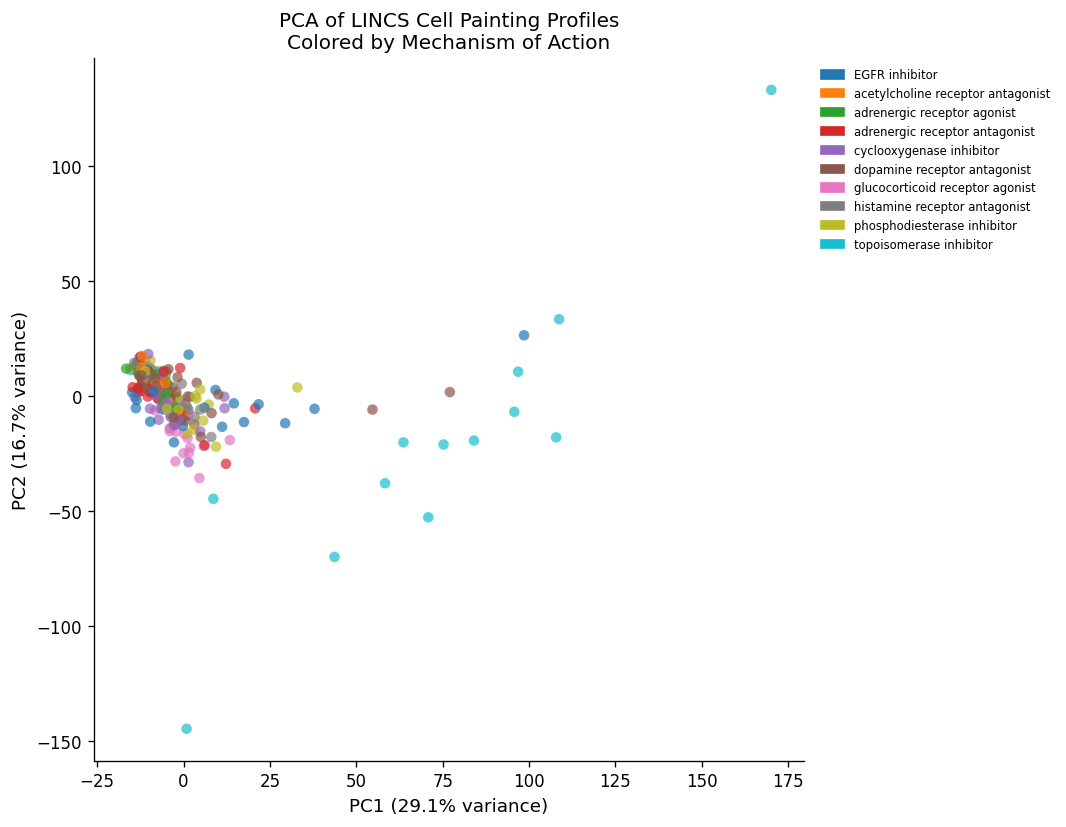

Saved: pca_moa.png


In [ ]:
# Run PCA and plot the first two principal components
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
print(f'PC1 explained variance: {explained[0]*100:.1f}%')
print(f'PC2 explained variance: {explained[1]*100:.1f}%')
print(f'Cumulative (50 PCs): {explained.sum()*100:.1f}%')

# Assign a color to each MoA class
unique_moas = sorted(set(labels))
palette = plt.cm.tab10.colors
color_map = {moa: palette[i % 10] for i, moa in enumerate(unique_moas)}
colors = [color_map[l] for l in labels]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7, s=40, edgecolors='none')

legend_patches = [mpatches.Patch(color=color_map[m], label=m) for m in unique_moas]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=7, frameon=False)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA of LINCS Cell Painting Profiles\nColored by Mechanism of Action', fontsize=12)
plt.tight_layout()
plt.savefig('pca_moa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pca_moa.png')

## Part 7: UMAP -- Visualizing MoA Clusters

PCA is linear -- it can only capture structure that lies in the directions of maximum variance. UMAP (Uniform Manifold Approximation and Projection) is a nonlinear dimensionality reduction method that is much better at preserving local structure -- meaning compounds that are similar in morphological feature space end up near each other in the 2D plot.

If the Cell Painting data has captured real MoA signal, we expect to see compounds with the same mechanism clustering together in the UMAP even without giving UMAP the labels -- it works purely from the morphological features.

Key UMAP parameters:
- `n_neighbors`: how many nearest neighbors to consider when building the graph (higher = more global structure)
- `min_dist`: minimum distance between points in the 2D embedding (lower = tighter clusters)
- We run UMAP on the first 50 PCs rather than all 1,783 features -- this reduces noise and speeds up computation

In [ ]:
# Run UMAP on the first 50 PCs
# Using PCA-reduced input speeds up UMAP and reduces noise from low-variance features
print('Running UMAP (this takes about 30-60 seconds on CPU)...')
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=42
)
X_umap = reducer.fit_transform(X_pca)
print(f'UMAP embedding shape: {X_umap.shape}')
print('Done.')

Running UMAP (this takes about 30-60 seconds on CPU)...
UMAP embedding shape: (273, 2)
Done.


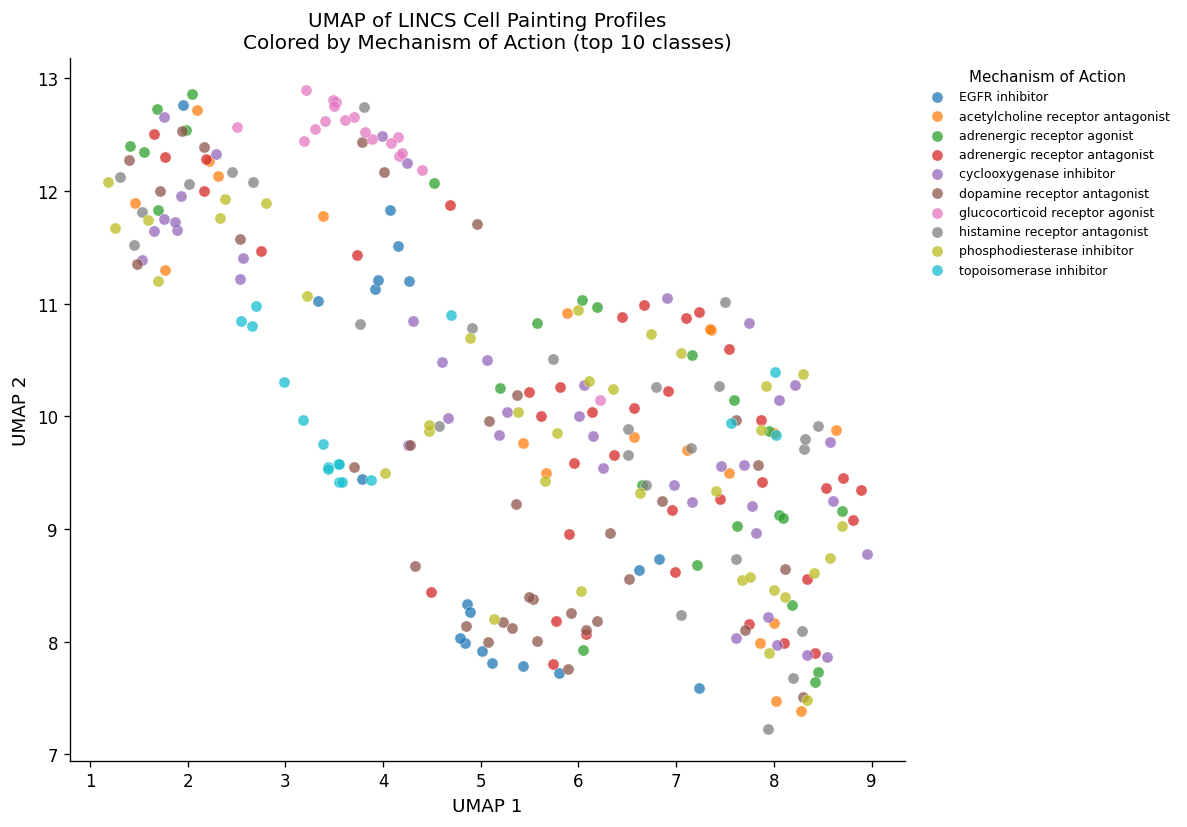

Saved: umap_moa.png


In [ ]:
# Plot UMAP colored by MoA class
fig, ax = plt.subplots(figsize=(10, 7))

for moa_class in unique_moas:
    mask = labels == moa_class
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        c=[color_map[moa_class]],
        label=moa_class,
        alpha=0.75,
        s=45,
        edgecolors='white',
        linewidths=0.3
    )

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7.5, frameon=False,
          title='Mechanism of Action', title_fontsize=9)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_title('UMAP of LINCS Cell Painting Profiles\nColored by Mechanism of Action (top 10 classes)', fontsize=12)
plt.tight_layout()
plt.savefig('umap_moa.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: umap_moa.png')

## Part 8: MoA Consensus Profiles

Instead of looking at individual compounds, we can compute the **average profile** for each MoA class -- the "consensus" of what that mechanism does to cell morphology. This makes the class-level signal clearer.

We will then look at which feature groups contribute most to the differences between MoA classes. This is where the biology becomes interpretable: if EGFR inhibitors stand out on mitochondrial texture features, that tells us something about downstream effects of EGFR signaling on mitochondrial morphology.

In [ ]:
# Compute mean profile per MoA class (in standardized feature space)
df_feat = pd.DataFrame(X, columns=feature_cols)
df_feat['moa_simple'] = labels

consensus = df_feat.groupby('moa_simple')[feature_cols].mean()
print(f'Consensus profiles shape: {consensus.shape}')
print(f'One row per MoA class, {consensus.shape[1]} features')
print(f'\nMoA classes in consensus:')
for m in consensus.index:
    print(f'  {m}')

Consensus profiles shape: (10, 1783)
One row per MoA class, 1783 features

MoA classes in consensus:
  EGFR inhibitor
  acetylcholine receptor antagonist
  adrenergic receptor agonist
  adrenergic receptor antagonist
  cyclooxygenase inhibitor
  dopamine receptor antagonist
  glucocorticoid receptor agonist
  histamine receptor antagonist
  phosphodiesterase inhibitor
  topoisomerase inhibitor


In [ ]:
# Identify the most discriminating features across MoA classes
# We use variance across MoA consensus profiles -- high variance means
# this feature differs a lot between mechanisms

feature_variance = consensus.var(axis=0)
top_features = feature_variance.nlargest(50).index.tolist()

print('Top 20 most discriminating features (highest variance across MoA classes):')
for i, f in enumerate(top_features[:20], 1):
    print(f'  {i:>2}. {f}')

Top 20 most discriminating features (highest variance across MoA classes):
   1. Nuclei_Neighbors_FirstClosestDistance_2
   2. Cells_Neighbors_FirstClosestDistance_10
   3. Cells_Neighbors_FirstClosestDistance_Adjacent
   4. Cells_Neighbors_SecondClosestDistance_10
   5. Cells_Neighbors_SecondClosestDistance_Adjacent
   6. Nuclei_Neighbors_SecondClosestDistance_2
   7. Nuclei_Texture_InverseDifferenceMoment_DNA_10_0
   8. Nuclei_Granularity_6_DNA
   9. Cells_RadialDistribution_FracAtD_Mito_2of4
  10. Cells_RadialDistribution_MeanFrac_Mito_4of4
  11. Cells_RadialDistribution_FracAtD_Mito_4of4
  12. Nuclei_Intensity_IntegratedIntensity_Mito
  13. Cells_RadialDistribution_FracAtD_Mito_1of4
  14. Cells_RadialDistribution_MeanFrac_Mito_2of4
  15. Cells_AreaShape_Zernike_3_3
  16. Nuclei_Granularity_11_DNA
  17. Cells_Neighbors_NumberOfNeighbors_Adjacent
  18. Nuclei_Texture_Entropy_DNA_10_0
  19. Nuclei_Granularity_10_AGP
  20. Cells_RadialDistribution_MeanFrac_Mito_1of4


## Part 9: Hierarchical Clustering Heatmap

With consensus profiles in hand, we can cluster the MoA classes by their morphological similarity. This is a **hierarchical clustering heatmap** -- the dendrogram on the rows shows which MoA classes are morphologically similar, and the color intensity shows the feature values.

We use only the top 50 most discriminating features to keep the heatmap interpretable. The full 1,783-feature heatmap would be too dense to read.

What to look for:
- MoA classes that cluster together share similar cellular phenotypes
- The color blocks show which feature groups drive each MoA cluster
- Well-separated branches in the dendrogram indicate mechanistically distinct compound classes

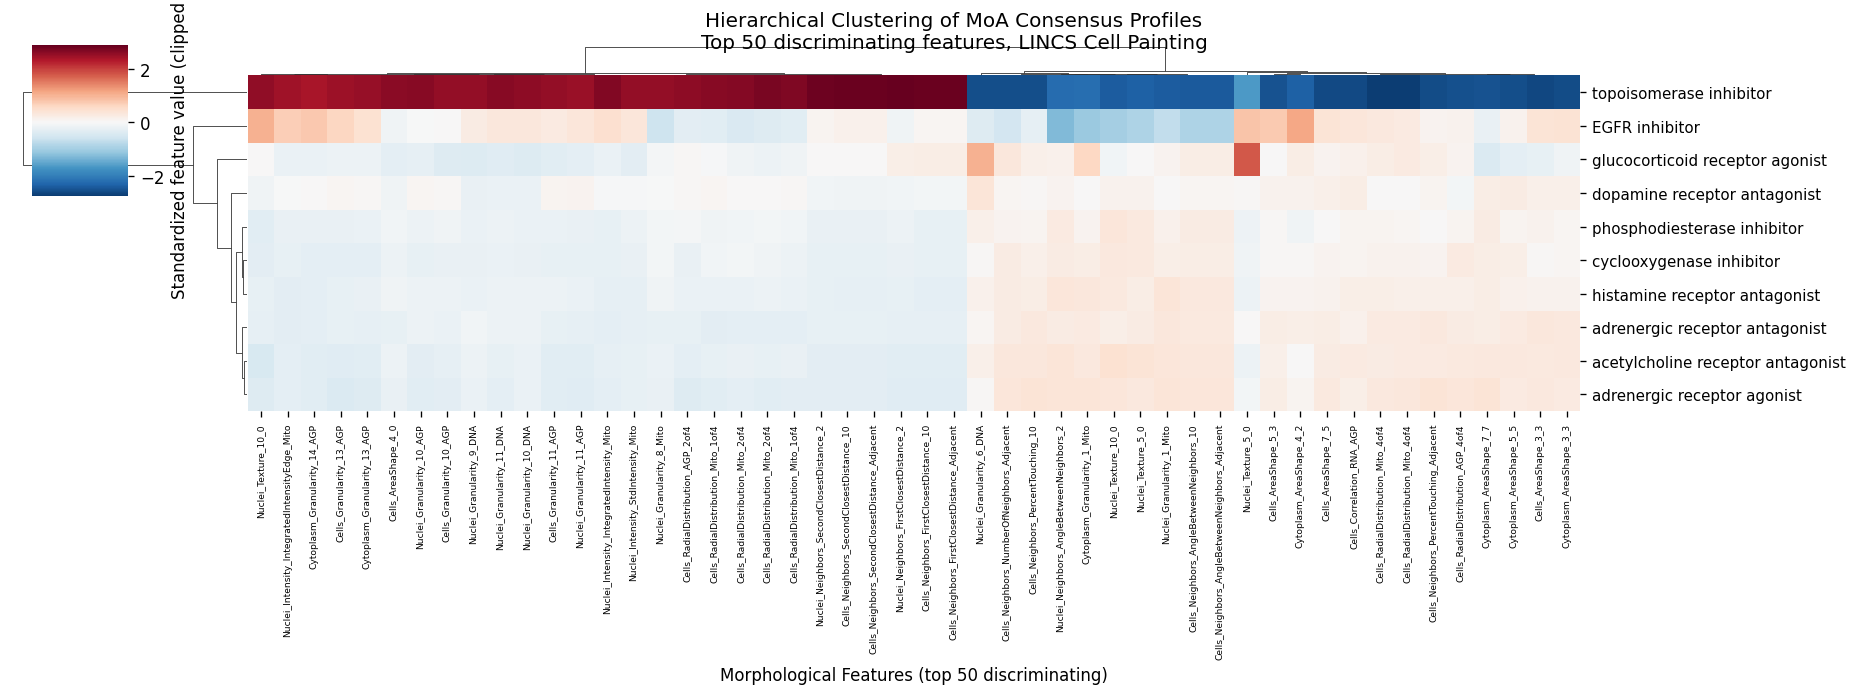

Saved: moa_clustermap.png


In [ ]:
# Hierarchical clustering heatmap of MoA consensus profiles
# Using top 50 discriminating features for readability

heatmap_data = consensus[top_features]

# Clip extreme values so a few outlier features don't dominate the color scale
heatmap_clipped = heatmap_data.clip(lower=-3, upper=3)

# Shorten feature names for display (keep compartment + family + last part)
short_names = []
for f in top_features:
    parts = f.split('_')
    if len(parts) >= 4:
        short_names.append(f'{parts[0]}_{parts[1]}_{"_".join(parts[-2:])}')
    else:
        short_names.append(f)
heatmap_clipped.columns = short_names

g = sns.clustermap(
    heatmap_clipped,
    method='ward',
    metric='euclidean',
    cmap='RdBu_r',
    center=0,
    figsize=(16, 7),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.15, 0.08),
    cbar_kws={'label': 'Standardized feature value (clipped to ±3)'},
    linewidths=0
)

g.ax_heatmap.set_xlabel('Morphological Features (top 50 discriminating)', fontsize=10)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=9)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=5.5, rotation=90)
g.fig.suptitle('Hierarchical Clustering of MoA Consensus Profiles\nTop 50 discriminating features, LINCS Cell Painting',
               y=1.02, fontsize=12)

plt.savefig('moa_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: moa_clustermap.png')

## Part 10: EGFR Inhibitors -- Connection to Video 5

In Video 5 we identified potential EGFR inhibitor hits using virtual screening with our QSAR model. The question we asked was: do these compounds have favorable predicted IC50 values against EGFR?

Cell Painting adds a complementary view. In the LINCS dataset, 15 known EGFR inhibitors were profiled. We can look at where they sit in the UMAP and what their morphological profile looks like relative to other kinase inhibitors or cytoskeletal drugs.

In a real drug discovery project, you would take your virtual screening hits, run a Cell Painting experiment on them, then check: do they cluster with known EGFR inhibitors in morphological profile space? If yes, that is strong evidence the compound is acting through the expected mechanism. If they cluster with, say, DNA-damaging agents, that would be a red flag.

Below we extract the EGFR inhibitor profiles from our current dataset and look at their morphological fingerprint.

In [ ]:
# Extract EGFR inhibitors from the full high-dose dataset (before top-10 filter)
egfr = high_dose[high_dose['moa'].str.contains('EGFR inhibitor', na=False)].copy()
print(f'EGFR inhibitors in dataset: {len(egfr)}')
print(f'Compound names: {egfr["pert_iname"].tolist()}')
print(f'Clinical phases: {egfr[["pert_iname", "clinical_phase"]].to_string(index=False)}')

EGFR inhibitors in dataset: 40
Compound names: ['PD-153035', 'regorafenib', 'lucitanib', 'lapatinib', 'pelitinib', 'sorafenib', 'AEE788', 'osimertinib', 'brivanib', 'rociletinib', 'TG-100801', 'BMS-599626', 'foretinib', 'lenvatinib', 'orantinib', 'MK-2461', 'dacomitinib', 'cabozantinib', 'tivozanib', 'ARRY-334543', 'canertinib', 'semaxanib', 'gefitinib', 'afatinib', 'nintedanib', 'telatinib', 'cediranib', 'TAK-285', 'neratinib', 'ENMD-2076', 'erlotinib', 'BIBX-1382', 'CP-724714', 'golvatinib', 'SU014813', 'pazopanib', 'vandetanib', 'linifanib', 'RAF265', 'AZD8931']
Clinical phases:   pert_iname  clinical_phase
   PD-153035         Phase 1
 regorafenib        Launched
   lucitanib         Phase 2
   lapatinib        Launched
   pelitinib         Phase 2
   sorafenib        Launched
      AEE788 Phase 1/Phase 2
 osimertinib        Launched
    brivanib         Phase 3
 rociletinib         Phase 3
   TG-100801         Phase 2
  BMS-599626         Phase 1
   foretinib         Phase 2
  len

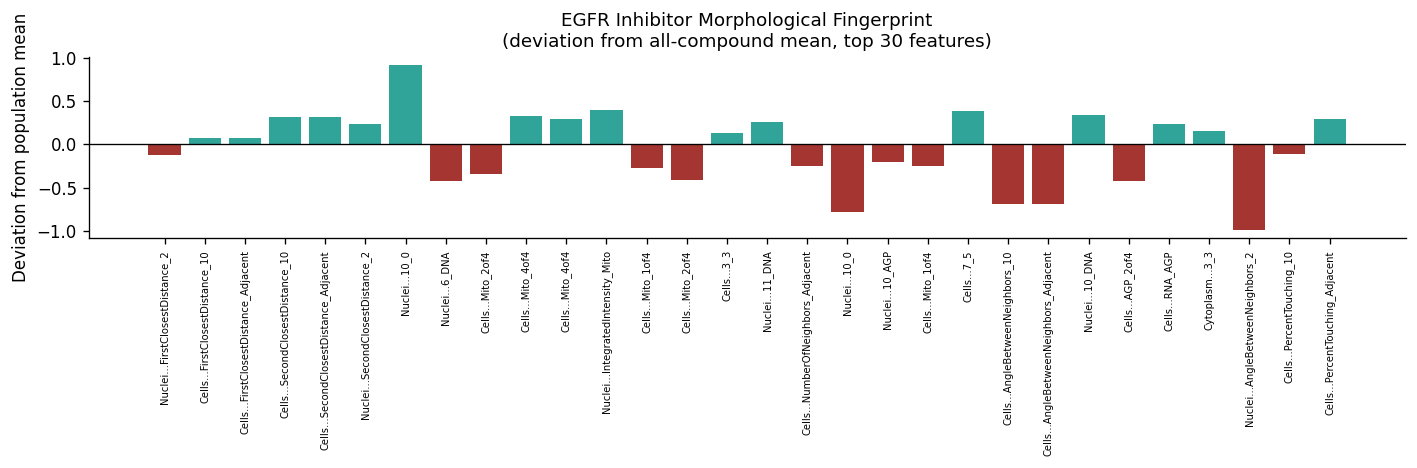

Saved: egfr_fingerprint.png


In [ ]:
# Show the EGFR inhibitor morphological fingerprint compared to the
# mean profile across all compounds (using the top discriminating features)

# Compute mean profile across all high-dose compounds (standardized)
X_high_raw = high_dose[feature_cols].values
X_high_imp = imputer.transform(X_high_raw)
X_high = scaler.transform(X_high_imp)

overall_mean = X_high.mean(axis=0)

# EGFR inhibitor mean profile
X_egfr_raw = egfr[feature_cols].values
X_egfr_imp = imputer.transform(X_egfr_raw)
X_egfr = scaler.transform(X_egfr_imp)
egfr_mean = X_egfr.mean(axis=0)

# Compute deviation of EGFR profile from overall mean for top features
top_feat_idx = [list(feature_cols).index(f) for f in top_features[:30]]
egfr_deviation = egfr_mean[top_feat_idx] - overall_mean[top_feat_idx]

fig, ax = plt.subplots(figsize=(12, 4))
x_pos = np.arange(len(top_features[:30]))
colors_bar = ['#0D9488' if v > 0 else '#94120D' for v in egfr_deviation]
ax.bar(x_pos, egfr_deviation, color=colors_bar, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
short_top30 = []
for f in top_features[:30]:
    parts = f.split('_')
    short_top30.append(f'{parts[0]}...{"_".join(parts[-2:])}')
ax.set_xticklabels(short_top30, rotation=90, fontsize=6)
ax.set_ylabel('Deviation from population mean', fontsize=10)
ax.set_title('EGFR Inhibitor Morphological Fingerprint\n(deviation from all-compound mean, top 30 features)', fontsize=11)
plt.tight_layout()
plt.savefig('egfr_fingerprint.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: egfr_fingerprint.png')

## Summary

In this notebook we walked through the full Cell Painting / morphological profiling workflow:

1. **The assay**: Cell Painting uses 5 fluorescent dyes to stain 8 cellular compartments simultaneously. CellProfiler extracts 1,000-2,000 morphological features per well.

2. **The data**: We loaded the LINCS Cell Painting dataset -- 1,571 compounds in A549 cells, published by the Broad Institute (CC0 license). After merging with MoA annotations and filtering to the highest dose and top 10 MoA classes, we had a clean dataset ready for analysis.

3. **Preprocessing**: Median imputation for missing values, then StandardScaler to put all 1,783 features on the same scale before dimensionality reduction.

4. **PCA**: Linear dimensionality reduction as a sanity check -- partial separation of MoA classes in PC1/PC2 confirms that biological signal is present in the data.

5. **UMAP**: Nonlinear dimensionality reduction that reveals tighter, more distinct MoA clusters. Compounds with the same mechanism cluster together even though UMAP receives no label information -- it works purely from morphological similarity.

6. **Hierarchical clustering**: A dendrogram + heatmap of MoA consensus profiles showing which mechanisms are morphologically similar and which features drive the separation.

7. **EGFR tie-in**: We extracted the morphological fingerprint of known EGFR inhibitors -- the same target we screened against in Video 5. In a real project, this fingerprint would serve as a reference for comparing against hits from virtual screening.

### Where this fits in the drug discovery pipeline

Cell Painting occupies the **phenotypic screening** stage -- after virtual screening and initial wet-lab assays, before lead optimization. Its main uses are:
- **MoA confirmation**: Does a hit cluster with known compounds of the expected mechanism?
- **Toxicity flags**: Does a compound cluster with known cytotoxic or DNA-damaging agents?
- **Mechanism discovery**: For compounds with unknown targets, guilt-by-association with profiled reference compounds can suggest the mechanism.

In Video 7 we move from population-level 2D imaging to single-object 3D analysis, looking at drug effects on 3D organoid models using volumetric segmentation and morphological feature extraction.